In [2]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [5]:
data=pd.read_csv("taxi_trip_pricing.csv")
data

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180
...,...,...,...,...,...,...,...,...,...,...,...
995,5.49,Afternoon,Weekend,4.0,Medium,Clear,2.39,0.62,0.49,58.39,34.4049
996,45.95,Night,Weekday,4.0,Medium,Clear,3.12,0.61,NaN,61.96,62.1295
997,7.70,Morning,Weekday,3.0,Low,Rain,2.08,1.78,NaN,54.18,33.1236
998,47.56,Morning,Weekday,1.0,Low,Clear,2.67,0.82,0.17,114.94,61.2090


In [8]:
print(data.head())

   Trip_Distance_km Time_of_Day Day_of_Week  Passenger_Count  \
0             19.35     Morning     Weekday              3.0   
1             47.59   Afternoon     Weekday              1.0   
2             36.87     Evening     Weekend              1.0   
3             30.33     Evening     Weekday              4.0   
4               NaN     Evening     Weekday              3.0   

  Traffic_Conditions Weather  Base_Fare  Per_Km_Rate  Per_Minute_Rate  \
0                Low   Clear       3.56         0.80             0.32   
1               High   Clear        NaN         0.62             0.43   
2               High   Clear       2.70         1.21             0.15   
3                Low     NaN       3.48         0.51             0.15   
4               High   Clear       2.93         0.63             0.32   

   Trip_Duration_Minutes  Trip_Price  
0                  53.82     36.2624  
1                  40.57         NaN  
2                  37.27     52.9032  
3                 11

In [9]:
print("\nMissing Value")
print(data.isnull().sum())


Missing Value
Trip_Distance_km         50
Time_of_Day              50
Day_of_Week              50
Passenger_Count          50
Traffic_Conditions       50
Weather                  50
Base_Fare                50
Per_Km_Rate              50
Per_Minute_Rate          50
Trip_Duration_Minutes    50
Trip_Price               49
dtype: int64


In [11]:
data.dropna(inplace=True)

In [12]:
data.drop_duplicates(inplace=True)

In [13]:
print("\nDataset Shape :", data.shape)


Dataset Shape : (562, 11)


In [15]:
print(data.info())

<class 'pandas.DataFrame'>
Index: 562 entries, 0 to 998
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       562 non-null    float64
 1   Time_of_Day            562 non-null    str    
 2   Day_of_Week            562 non-null    str    
 3   Passenger_Count        562 non-null    float64
 4   Traffic_Conditions     562 non-null    str    
 5   Weather                562 non-null    str    
 6   Base_Fare              562 non-null    float64
 7   Per_Km_Rate            562 non-null    float64
 8   Per_Minute_Rate        562 non-null    float64
 9   Trip_Duration_Minutes  562 non-null    float64
 10  Trip_Price             562 non-null    float64
dtypes: float64(7), str(4)
memory usage: 43.9 KB
None


In [16]:
x1=data["Trip_Distance_km"]
x2=data["Passenger_Count"]
x3=data["Per_Km_Rate"]
y=data["Trip_Price"]

In [17]:
x1

0      19.35
2      36.87
5       8.64
12     41.79
14      9.91
       ...  
990    40.17
992    14.34
994    18.69
995     5.49
998    47.56
Name: Trip_Distance_km, Length: 562, dtype: float64

In [18]:
x2

0      3.0
2      1.0
5      2.0
12     3.0
14     2.0
      ... 
990    3.0
992    1.0
994    3.0
995    4.0
998    1.0
Name: Passenger_Count, Length: 562, dtype: float64

In [19]:
x3

0      0.80
2      1.21
5      1.71
12     1.77
14     1.26
       ... 
990    0.66
992    1.01
994    1.79
995    0.62
998    0.82
Name: Per_Km_Rate, Length: 562, dtype: float64

In [20]:
y

0      36.2624
2      52.9032
5      60.2028
12     88.1328
14     28.9914
        ...   
990    56.6394
992    30.7837
994    51.8548
995    34.4049
998    61.2090
Name: Trip_Price, Length: 562, dtype: float64

In [21]:
X = np.column_stack((x1, x2, x3))
Y = np.array(y)

In [23]:
model = LinearRegression()
model.fit(X, Y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [24]:
import numpy as np
new_distance=float(input("Enter your Distance of km:"))
new_counts=float(input("Enter your passanger counts:"))
new_Km_Rate=float(input("Enter your Per_Km_Rate:"))
new_x=np.column_stack((new_distance, new_counts, new_Km_Rate))
print("Predicted price:",model.predict(new_x))

Enter your Distance of km: 6.0
Enter your passanger counts: 3.0
Enter your Per_Km_Rate: 7.0


Predicted price: [177.39821827]


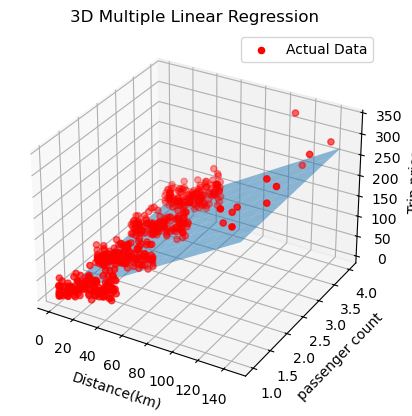

In [33]:
import matplotlib.pyplot as pl
from mpl_toolkits.mplot3d import Axes3D
x1_range=np.linspace(min(x1),max(x1),10)
x2_range=np.linspace(min(x2),max(x2),10)
x1_grid, x2_grid=np.meshgrid(x1_range,x2_range)
y_grid=model.predict(np.column_stack((x1_grid.ravel(),x2_grid.ravel()))).reshape(x1_grid.shape)
fig=plt.figure()
ax=fig.add_subplot(111,projection='3d')
ax.scatter(x1,x2,y,color='red',label='Actual Data')
ax.plot_surface(x1_grid,x2_grid,y_grid, alpha=0.5)
ax.set_xlabel("Distance(km)")
ax.set_ylabel("passenger count")
ax.set_zlabel("Trip price")
ax.set_title("3D Multiple Linear Regression")
plt.legend()
plt.show()

In [34]:
accuraccy=r2_score(y,model.predict(X))
print("Accuraccy:",accuraccy)

Accuraccy: 0.7468210257871952
